# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import SamplerV2



In [2]:
# =====================================================
# IBM Quantum hardware configuration
# =====================================================

# Set to True when you actually want to submit jobs to IBM.
run_ibm = True

# IBM QPU
ibm_backend_name = "ibm_kingston"

# Hardware shots
ibm_shots = 1024

# IBM Runtime error mitigation
ibm_resilience_level = 2

# ZNE
ibm_zne_noise_factors = (1, 2, 3)
ibm_zne_extrapolator = "linear"

# Dynamical decoupling
ibm_dd_enable = True
ibm_dd_sequence = "XpXm"

# Gate Pauli twirling
ibm_gate_twirling = True

# TREX / measurement twirling
ibm_measure_twirling = True

# IBM hardware sampling times.
# Deliberately independent of the dense simulator/analytic time grid.
ibm_times = np.array([0., 0.1, 0.5, 1., 1.5, 2.])

print("IBM backend:", ibm_backend_name)
print("IBM measurement times:", ibm_times)
print("IBM shots:", ibm_shots)
print("IBM resilience level:", ibm_resilience_level)
print("IBM ZNE factors:", ibm_zne_noise_factors)
print("IBM ZNE extrapolator:", ibm_zne_extrapolator)
print("IBM DD:", ibm_dd_enable, ibm_dd_sequence)
print("IBM gate twirling:", ibm_gate_twirling)
print("IBM TREX:", ibm_measure_twirling)

IBM backend: ibm_kingston
IBM measurement times: [0.  0.1 0.5 1.  1.5 2. ]
IBM shots: 1024
IBM resilience level: 2
IBM ZNE factors: (1, 2, 3)
IBM ZNE extrapolator: linear
IBM DD: True XpXm
IBM gate twirling: True
IBM TREX: True


In [3]:
# =====================================================
# IBM Runtime service
# =====================================================

ibm_service = None
ibm_backend = None
ibm_sampler = None


def initialize_ibm_runtime():
    """
    Initialize IBM Quantum Runtime and the selected QPU.

    IBM account credentials are stored locally using
    QiskitRuntimeService.save_account(...).
    """

    global ibm_service, ibm_backend, ibm_sampler

    # -------------------------------------------------
    # Connect to IBM Quantum Open Plan
    # -------------------------------------------------

    ibm_service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        instance="open-instance",
    )

    # -------------------------------------------------
    # Select backend
    # -------------------------------------------------

    ibm_backend = ibm_service.backend(
        ibm_backend_name
    )

    print(f"Connected to IBM backend: {ibm_backend.name}")
    print(f"Number of qubits: {ibm_backend.num_qubits}")

    # -------------------------------------------------
    # Sampler V2
    # -------------------------------------------------

    ibm_sampler = SamplerV2(
        mode=ibm_backend
    )

    # -------------------------------------------------
    # Shots
    # -------------------------------------------------

    ibm_sampler.options.default_shots = ibm_shots

    # -------------------------------------------------
    # Dynamical decoupling
    # -------------------------------------------------

    ibm_sampler.options.dynamical_decoupling.enable = (
        ibm_dd_enable
    )

    ibm_sampler.options.dynamical_decoupling.sequence_type = (
        ibm_dd_sequence
    )

    # -------------------------------------------------
    # Gate Pauli twirling
    # -------------------------------------------------

    ibm_sampler.options.twirling.enable_gates = (
        ibm_gate_twirling
    )

    # -------------------------------------------------
    # Measurement twirling
    # -------------------------------------------------

    ibm_sampler.options.twirling.enable_measure = (
        ibm_measure_twirling
    )

    # -------------------------------------------------
    # Print configuration
    # -------------------------------------------------

    print("\nIBM Runtime SamplerV2 configured.")
    print("  Backend              :", ibm_backend.name)
    print("  Shots                :", ibm_shots)
    print("  Dynamical decoupling :", ibm_dd_enable)
    print("  DD sequence          :", ibm_dd_sequence)
    print("  Gate twirling        :", ibm_gate_twirling)
    print("  Measurement twirling :", ibm_measure_twirling)

In [4]:
# =====================================================
# IBM observable construction
# =====================================================

def make_ibm_z_observable(N, qubit):
    """
    Construct the single-qubit Z observable acting on `qubit`.

    Qiskit's Pauli strings are written with qubit N-1 on the left
    and qubit 0 on the right.
    """
    pauli = ["I"] * N
    pauli[N - 1 - qubit] = "Z"

    return SparsePauliOp.from_list([
        ("".join(pauli), 1.0)
    ])

In [5]:
import argparse

parser = argparse.ArgumentParser(
    description="Many-body vs Random-Phase neutrino oscillation simulation"
)

parser.add_argument(
    "--Ne",
    type=int,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    help="Number of initially x-flavor neutrinos",
)

args, _ = parser.parse_known_args()

if args.Ne is None:
    Ne = int(input("Enter the number of electron-flavor neutrinos (Ne): "))
else:
    Ne = args.Ne

if args.Nx is None:
    Nx = int(input("Enter the number of x-flavor neutrinos (Nx): "))
else:
    Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  2
Enter the number of x-flavor neutrinos (Nx):  8


In [6]:
# =============================
# CELL 1: Imports and parameters
# =============================

# -----------------------------
# Particle numbers
# -----------------------------


# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = 1

# -----------------------------
# Evolution choices
# -----------------------------
# Keep these False to match the later cells of the old e1_x15 notebook:
# self-interaction only, with no vacuum and no matter term.
use_vacuum = False
use_matter = False

# -----------------------------
# Time / Trotter / sampling parameters
# -----------------------------
dt = 0.05
T_max = 2.0 #200.0
sample_every = 4

n_steps_max = int(round(T_max / dt))
times = np.arange(0, n_steps_max + 1, sample_every) * dt

# -----------------------------
# Qiskit simulation parameters
# -----------------------------
shots = 1024
seed_simulator = 12345
backend = AerSimulator(seed_simulator=seed_simulator)

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(f"Number of sampled times = {len(times)}, T_max = {T_max}, dt = {dt}")
print(f"Evolution mode: self-interaction only = {not use_vacuum and not use_matter}")

Using Ne = 2, Nx = 8, total N = 10
omega1 = 0.25
mu = omega1 * N = 1
Number of sampled times = 11, T_max = 2.0, dt = 0.05
Evolution mode: self-interaction only = True


In [7]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================



#J = interaction_matrix(N, dm2, E)
J=1
#print("J shape =", J.shape)
#print("J min/max =", J.min(), J.max())

In [8]:
# =========================================
# CELL 3: Qiskit evolution building blocks
# =========================================

def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    This function is retained for completeness, but use_vacuum=False by default
    to match the old e1_x15 comparison.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


def add_interaction_evolution(qc, n, J, N, dt):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply approximately

        exp[-i Jij dt (XX + YY + ZZ)]

    using

        RXX(2 Jij dt) RYY(2 Jij dt) RZZ(2 Jij dt).
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 1.0 * J* dt
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)


def add_interaction_evolution_ibm(qc, n, J, N, dt):
    """
    Add n first-order all-to-all interaction steps using
    an explicit linear SWAP network for IBM hardware.

    For every Trotter step, every logical qubit pair interacts
    exactly once.

    Each interaction is

        RXX(phi) RYY(phi) RZZ(phi)

    with

        phi = J * dt

    matching add_interaction_evolution().
    """

    for _ in range(n):

        # Logical qubit occupying each physical position.
        # Initially: [0, 1, 2, ..., N-1]
        order = list(range(N))

        for layer in range(N - 1):

            # Alternate even and odd nearest-neighbour pairs
            start = layer % 2

            # -------------------------------------------------
            # Interaction layer
            # -------------------------------------------------
            for k in range(start, N - 1, 2):

                # These are the logical qubits currently
                # occupying physical positions k and k+1.
                i = order[k]
                j = order[k + 1]

                # Same scalar J as in the original function
                phi = J * dt

                qc.rxx(phi, k, k + 1)
                qc.ryy(phi, k, k + 1)
                qc.rzz(phi, k, k + 1)

            # -------------------------------------------------
            # SWAP layer
            # -------------------------------------------------
            #
            # No SWAP after the final interaction layer.
            #
            if layer < N - 2:

                swap_start = 1 - start

                for k in range(swap_start, N - 1, 2):

                    qc.swap(k, k + 1)

                    # Update logical-qubit positions
                    order[k], order[k + 1] = (
                        order[k + 1],
                        order[k],
                    )

In [9]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Parameters
    ----------
    t_table : array
        Sampled times.
    theta : float
        Vacuum mixing angle.
    omega : array
        Vacuum frequencies for all modes.
    lam : float
        Matter strength.
    J : array
        Coupling matrix.
    initial_flavors : array
        Entries may be:
            'e'  : |nu_e>
            'x'  : |nu_mu>
            'mu' : |nu_mu>
            'a'  : cos(alpha)|nu_e> + sin(alpha)|nu_mu>
    alpha : float
        Superposition angle for every mode labeled 'a'.
    """
    n_modes = omega.size

    u = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T
    l = np.diag([1, 0])

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    B = np.real(np.array([np.trace(b @ sigma_1),
                          np.trace(b @ sigma_2),
                          np.trace(b @ sigma_3)]))
    L = np.real(np.array([np.trace(l @ sigma_1),
                          np.trace(l @ sigma_2),
                          np.trace(l @ sigma_3)]))

    ini_state = np.where(omega > 0, Ee[:, None], Emu[:, None])

    if initial_flavors is not None:
        initial_flavors = np.asarray(initial_flavors)

        for f in initial_flavors:
            if f not in ["e", "x", "mu", "a"]:
                raise ValueError(f"Unknown flavor label: {f}")
            if f == "a" and alpha is None:
                raise ValueError("Flavor label 'a' requires alpha.")

        ini_state[:, initial_flavors == "e"] = Ee[:, None]
        ini_state[:, initial_flavors == "x"] = Emu[:, None]
        ini_state[:, initial_flavors == "mu"] = Emu[:, None]
        ini_state[:, initial_flavors == "a"] = np.array(
            [np.sin(2.0 * alpha), 0.0, np.cos(2.0 * alpha)]
        )[:, None]

    def rhs(t, P_flat):
        """
        dP_k/dt = H_k x P_k,
        H_k = omega_k B + lambda L + sum_j J_kj P_j.
        """
        res = np.zeros(3 * n_modes)
        PP = np.reshape(P_flat, (n_modes, 3)).T
        
        for k in range(n_modes):
            H_k = omega[k] * B + lam * L + J * np.sum(PP, axis=1)
            res[3*k:3*k+3] = np.cross(H_k, PP[:, k])

        return res
    
    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
    )

In [10]:
# =====================================================
# CELL 5: Many-body Qiskit solver for Ne + Nx(alpha)
# =====================================================

def prepare_initial_circuit(Ne, Nx, alpha):
    """
    Prepare the initial many-body state:

        first Ne qubits: |nu_e> = |0>
        next  Nx qubits: |nu_x(alpha)> = cos(alpha)|0> + sin(alpha)|1>

    RY(2 alpha)|0> = cos(alpha)|0> + sin(alpha)|1>.

    For alpha = pi/2, the Nx group is exactly |1>, reproducing
    the old 1 nu_e + 15 nu_mu setup when Ne=1, Nx=15.
    """
    N = Ne + Nx
    qc0 = QuantumCircuit(N, N)

    # First Ne qubits are |nu_e> = |0>, so no gate is needed.
    for q in range(Ne, N):
        qc0.ry(2.0 * alpha, q)

    return qc0


def run_many_body_qiskit(alpha, Ne, Nx, J, times, dt, shots, backend,
                         use_vacuum=False, bx=0.0, by=0.0, bz=0.0,
                         verbose=True):
    """
    Run the many-body Qiskit simulation for a given alpha.

    Output
    ------
    P_bit1[q, k] :
        Probability that qubit q is measured as |1> at time times[k].

    For the first Ne qubits, which start as |nu_e>=|0>,
        P_bit1 = P(nu_e -> nu_mu).

    The plotted observable is the Ne-average:
        <P(nu_e -> nu_mu)> over the initially electron-flavor group.
    """
    N = Ne + Nx
    qc0 = prepare_initial_circuit(Ne, Nx, alpha)

    P_bit1 = [[] for _ in range(N)]

    for t in times:
        n = int(round(t / dt))
        qc = qc0.copy()

        #if use_vacuum:
            #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

        add_interaction_evolution(qc, n=n, J=J, N=N, dt=dt)

        qc.measure(range(N), range(N))

        tqc = transpile(qc, backend, optimization_level=0)
        counts = backend.run(tqc, shots=shots).result().get_counts()

        p1_t = [0.0] * N

        for bitstring, c in counts.items():
            prob = c / shots

            for q in range(N):
                # Qiskit displays bitstrings with the highest classical bit first.
                bit_q = int(bitstring[-1 - q])
                if bit_q == 1:
                    p1_t[q] += prob

        for q in range(N):
            P_bit1[q].append(p1_t[q])

        if verbose:
            print(
                f"alpha={alpha:.6f}, t={t:8.3f}: "
                f"<P_e_to_mu>_MB = {np.mean(p1_t[:Ne]):.5f}"
            )

    P_bit1 = np.array(P_bit1)

    return {
        "P_bit1": P_bit1,
        "P_e_to_mu_avg": np.mean(P_bit1[:Ne, :], axis=0),
    }

In [11]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for the same initial state.

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem, matching
    the old e1_x15 comparison.
    """
    N = Ne + Nx

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    lam = 1.0 if use_matter else 0.0

    initial_flavors = np.array(["e"] * Ne + ["a"] * Nx)

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    P_all = sol.y
    P = P_all.reshape(N, 3, -1)
    Pz = P[:, 2, :]

    # P(nu_mu) = (1 - Pz)/2 for each mode.
    P_mu = 0.5 * (1.0 - Pz)

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": np.mean(P_mu[:Ne, :], axis=0),
    }


def run_alpha_case(alpha, verbose=True):
    """
    Run both many-body Qiskit and RS mean-field for one alpha.
    """
    N = Ne + Nx
    J = 1

    mb = run_many_body_qiskit(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        dt=dt,
        shots=shots,
        backend=backend,
        use_vacuum=use_vacuum,
        bx=bx,
        by=by,
        bz=bz,
        verbose=verbose,
    )

    rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    return {
        "alpha": alpha,
        "Ne": Ne,
        "Nx": Nx,
        "many_body": mb,
        "rs": rs,
    }

In [12]:
# =====================================================
# CELL 7: Plotting helpers
# =====================================================

results = {}

# Choose the x-axis used in all plots.
# Options:
#     "t"    : physical notebook time
#     "t_mu" : dimensionless t*mu
plot_time_axis = "t"


def get_plot_time():
    if plot_time_axis == "t":
        return times, r"Total time"
    elif plot_time_axis == "t_mu":
        return times , r"$t\mu$"
    else:
        raise ValueError("plot_time_axis must be either 't' or 't_mu'.")


def run_and_plot_alpha(alpha, alpha_label, fig_no=None, verbose=True, show_plot=True):
    """
    Run one alpha case and optionally plot the average conversion probability
    of the initially electron-flavor group.
    """
    key = alpha_label
    result = run_alpha_case(alpha, verbose=verbose)
    results[key] = result

    if show_plot:
        P_mb = result["many_body"]["P_e_to_mu_avg"]
        P_rs = result["rs"]["P_e_to_mu_avg"]

        x, xlabel = get_plot_time()

        plt.figure(figsize=(9, 5.5))

        plt.plot(
            x,
            P_mb,
            marker="o",
            linestyle="dashed",
            label=rf"Many-body Qiskit, $\alpha={alpha_label}$",
        )

        plt.plot(
            x,
            P_rs,
            linestyle="-",
            linewidth=2,
            label=rf"RS mean field, $\alpha={alpha_label}$",
        )

        plt.xlabel(xlabel)
        plt.ylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")

        if fig_no is None:
            plt.title(
                rf"$N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )
        else:
            plt.title(
                rf"Fig. {fig_no}: $N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

In [13]:
# =====================================================
# IBM hardware circuit from the general Hamiltonian
# =====================================================

def build_ibm_circuit(alpha, Ne, Nx, J, t, dt):
    """
    Construct the many-body evolution circuit for IBM.

    The physical interaction Hamiltonian is supplied as a
    SparsePauliOp and evolved using PauliEvolutionGate.

    IBM's transpiler is then responsible for converting this
    circuit into hardware-compatible gates and routing it
    according to the actual QPU connectivity.
    """

    N = Ne + Nx

    qc = prepare_initial_circuit(Ne, Nx, alpha)

    # General physical interaction Hamiltonian
    

    n = int(round(t / dt))

    # -------------------------------------------------
    # First-order Trotter evolution
    #
    # exp(-i H_int dt)
    #
    # repeated n times.
    # -------------------------------------------------

    add_interaction_evolution(qc, n=n, J=J, N=N, dt=dt)

    return qc

def transpile_ibm_circuit(qc, backend):
    """
    Transpile an abstract Hamiltonian-evolution circuit
    into the ISA of the selected IBM backend.
    """

    tqc = transpile(
        qc,
        backend=backend,
        optimization_level=3,
    )

    return tqc

In [14]:
from qiskit import ClassicalRegister
def run_many_body_ibm(
    alpha,
    Ne,
    Nx,
    J,
    times,
    dt,
    sampler,
    backend,
    shots=shots,
    verbose=True,
):

    N = Ne + Nx

    # =====================================================
    # Initialize storage
    # =====================================================

    P_bit1 = [[] for _ in range(N)]
    P_bit1_std = [[] for _ in range(N)]

    P_e_to_mu_avg = []
    P_e_to_mu_std = []

    # Store all transpiled circuits
    transpiled_circuits = []

    # Store circuit depths
    circuit_depths = []

    # =====================================================
    # IBM run information
    # =====================================================

    if verbose:
        print()
        print("=" * 60)
        print("Preparing IBM hardware run")
        print("=" * 60)
        print(f"alpha       = {alpha:.6f}")
        print(f"Ne          = {Ne}")
        print(f"Nx          = {Nx}")
        print(f"N           = {N}")
        print(f"J           = {J}")
        print(f"dt          = {dt}")
        print(f"shots       = {shots}")
        print(f"time points = {len(times)}")
        print(f"backend     = {backend.name}")
        print("=" * 60)

    # =====================================================
    # 1. Build and transpile ALL time points
    # =====================================================

    if verbose:
        print()
        print("Preparing all circuits...")
        print()

    for t in times:

        # -------------------------------------------------
        # Build abstract circuit
        # -------------------------------------------------

        qc = build_ibm_circuit(
            alpha=alpha,
            Ne=Ne,
            Nx=Nx,
            J=J,
            t=t,
            dt=dt,
        )

        # -------------------------------------------------
        # Add measurements
        # -------------------------------------------------

        # Use the one existing classical register
        creg = qc.cregs[0]

        # Add measurements
        qc.measure(range(N), creg)

        

        # -------------------------------------------------
        # Transpile
        # -------------------------------------------------
        
        tqc = transpile_ibm_circuit(
            qc,
            backend=backend
        )
        
        job = sampler.run([tqc], shots=shots)
        result = job.result()

        bit_array = result[0].data.c
        counts = bit_array.get_counts()
        # -------------------------------------------------
        # Store circuit and depth
        # -------------------------------------------------

        transpiled_circuits.append(tqc)

        depth = tqc.depth()
        circuit_depths.append(depth)

    # =====================================================
    # 2. Print ALL circuit depths before submitting
    # =====================================================

    if verbose:

        print("=" * 60)
        print("Prepared IBM circuits")
        print("=" * 60)

        for t, depth in zip(times, circuit_depths):

            n_steps = int(round(t / dt))

            print(
                f"t={t:8.3f} | "
                f"steps={n_steps:5d} | "
                f"depth={depth:6d}"
            )

        print("=" * 60)

    # =====================================================
    # 3. Submit ALL time points in ONE SamplerV2 job
    # =====================================================

    if verbose:
        print()
        print("=" * 60)
        print("Submitting IBM job")
        print("=" * 60)
        print(f"alpha       = {alpha:.6f}")
        print(f"time points = {len(times)}")
        print(f"shots       = {shots}")
        print("=" * 60)

    job = sampler.run(
        transpiled_circuits,
        shots=shots
    )

    if verbose:
        print("IBM job ID:", job.job_id())
        print("Waiting for IBM job to finish...")

    # =====================================================
    # 4. Wait for the single job
    # =====================================================

    results = job.result()

    if verbose:
        print("IBM job completed.")

    # =====================================================
    # 5. Extract result for EVERY time point
    # =====================================================

    for i, (t, pub_result) in enumerate(
        zip(times, results)
    ):

        # -------------------------------------------------
        # Extract measurement data
        # -------------------------------------------------

        bit_array = pub_result.data.c

        counts = bit_array.get_counts()
        if verbose:
            print(f"\nRaw counts for t={t:.3f}:")
            print(counts)
            print(f"Total shots: {sum(counts.values())}")
        # -------------------------------------------------
        # Calculate P(bit=1) for every qubit
        # -------------------------------------------------

        p1_t = [0.0] * N
        p1_std_t = [0.0] * N

        for q in range(N):

            n1 = 0

            for bitstring, c in counts.items():

                bit_q = int(bitstring[-1 - q])

                if bit_q == 1:
                    n1 += c

            # Probability of |1>
            p = n1 / shots

            # Binomial statistical uncertainty
            sigma = np.sqrt(
                p * (1.0 - p) / shots
            )

            p1_t[q] = p
            p1_std_t[q] = sigma

        # -------------------------------------------------
        # Store individual qubit results
        # -------------------------------------------------

        for q in range(N):

            P_bit1[q].append(p1_t[q])
            P_bit1_std[q].append(p1_std_t[q])

        # -------------------------------------------------
        # Average over initially-electron qubits
        # -------------------------------------------------

        P_avg = np.mean(p1_t[:Ne])

        P_avg_std = (
            np.sqrt(
                np.sum(
                    np.asarray(p1_std_t[:Ne]) ** 2
                )
            )
            / Ne
        )

        P_e_to_mu_avg.append(P_avg)
        P_e_to_mu_std.append(P_avg_std)

        # -------------------------------------------------
        # Print result
        # -------------------------------------------------

        if verbose:

            print(
                f"t={t:8.3f}: "
                f"P_e_to_mu="
                f"{P_avg:.6f} ± {P_avg_std:.6f}"
            )

    # =====================================================
    # 6. Convert to numpy arrays
    # =====================================================

    P_bit1 = np.asarray(P_bit1)
    P_bit1_std = np.asarray(P_bit1_std)

    P_e_to_mu_avg = np.asarray(P_e_to_mu_avg)
    P_e_to_mu_std = np.asarray(P_e_to_mu_std)

    circuit_depths = np.asarray(circuit_depths)

    # =====================================================
    # 7. Final summary
    # =====================================================

    if verbose:

        print()
        print("=" * 60)
        print("IBM run completed")
        print("=" * 60)

        for t, p, sp in zip(
            times,
            P_e_to_mu_avg,
            P_e_to_mu_std,
        ):

            print(
                f"t={t:8.3f} : "
                f"P_e_to_mu={p:.6f} ± {sp:.6f}"
            )

        print("=" * 60)

    # =====================================================
    # Return
    # =====================================================

    return {
        "times": np.asarray(times),

        "P_bit1": P_bit1,
        "P_bit1_std": P_bit1_std,

        "P_e_to_mu_avg": P_e_to_mu_avg,
        "P_e_to_mu_std": P_e_to_mu_std,

        "circuit_depths": circuit_depths,
    }

In [15]:
# =====================================================
# IBM alpha-case runner
# =====================================================

ibm_results = {}


def run_alpha_case_ibm(alpha, alpha_label, verbose=True):

    if not run_ibm:
        raise RuntimeError(
            "run_ibm=False. Set run_ibm=True before submitting "
            "to IBM Quantum."
        )

    if ibm_sampler is None:
        raise RuntimeError(
            "IBM SamplerV2 is not initialized. "
            "Initialize ibm_sampler before submitting "
            "to IBM Quantum."
        )

    result = run_many_body_ibm(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=ibm_times,
        dt=dt,
        sampler=ibm_sampler,
        backend=ibm_backend,
        shots=shots,
        verbose=verbose,
    )

    ibm_results[alpha_label] = result

    return result

## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [16]:
import numpy as np
from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S


def cg_coefficient(j1, m1, j2, m2, J, M):
    """
    Clebsch-Gordan coefficient

        <j1,m1; j2,m2 | J,M>

    using the SymPy convention.
    """
    return float(
        clebsch_gordan(
            sympy_S(j1),
            sympy_S(j2),
            sympy_S(J),
            sympy_S(m1),
            sympy_S(m2),
            sympy_S(M)
        )
    )


def collective_oscillation_probability(N1, N2, alpha, t, lam=1.0):
    """
    Collective nu_e -> nu_mu oscillation probability for a two-beam system.

    Parameters
    ----------
    N1 : int
        Number of initial nu_e neutrinos in beam 1.

    N2 : int
        Number of neutrinos in beam 2.

    alpha : float
        Mixing angle appearing in
            |x> = cos(alpha)|e> + sin(alpha)|mu>.

    t : float or array-like
        Evolution time.

    lam : float, optional
        Interaction strength lambda.

    Returns
    -------
    P_emu : float or ndarray
        Collective nu_e -> nu_mu conversion probability
        for a neutrino in beam 1.
    """

    # ------------------------------------------------------------
    # Input checks
    # ------------------------------------------------------------

    if N1 < 1 or N2 < 1:
        raise ValueError("N1 and N2 must be positive integers.")

    if not isinstance(N1, (int, np.integer)):
        raise TypeError("N1 must be an integer.")

    if not isinstance(N2, (int, np.integer)):
        raise TypeError("N2 must be an integer.")

    # ------------------------------------------------------------
    # Spin quantum numbers of the two beams
    # ------------------------------------------------------------

    j1 = N1 / 2
    j2 = N2 / 2

    # Maximum total spin
    Jmax = j1 + j2

    # Make t an array so that the same code works for
    # scalar or array-valued t
    t = np.asarray(t, dtype=float)

    # Total expected number of muon neutrinos in beam 1
    Nmu = np.zeros_like(t, dtype=float)

    c = np.cos(alpha)
    s = np.sin(alpha)

    # ============================================================
    # SPECIAL CASE: alpha = pi/2
    #
    # |x> = |mu>
    #
    # Therefore only i = N2 contributes.
    # ============================================================

    if np.isclose(alpha, np.pi / 2):

        i = N2

        # Total magnetic quantum number
        M = Jmax - i

        # Allowed minimum total spin
        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions in beam 1
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state:
            #
            # |j1, j1> |j2, j2-i>
            #
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state:
            #
            # |j1, j1-j> |j2, j2-i+j>
            #
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient of the initial state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient of the final state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Since the weight of the i=N2 sector is exactly 1,
            # directly add j * P_ij.
            Nmu += j * P_ij

        # Probability for one neutrino in beam 1
        return Nmu / N1

    # ============================================================
    # GENERAL CASE: alpha != pi/2
    # ============================================================

    for i in range(1, N2 + 1):

        # --------------------------------------------------------
        # Total magnetic quantum number
        # --------------------------------------------------------

        M = Jmax - i

        # --------------------------------------------------------
        # Weight of the i-th sector
        #
        # C(N2, i)
        # * (cos^2 alpha)^(N2-i)
        # * (sin^2 alpha)^i
        #
        # Calculate using logarithms for numerical stability.
        # --------------------------------------------------------

        if c != 0:
            log_weight = (
                gammaln(N2 + 1)
                - gammaln(i + 1)
                - gammaln(N2 - i + 1)
                + 2 * (N2 - i) * np.log(abs(c))
            )
        else:
            # If cos(alpha)=0, this sector has zero weight
            # for every i < N2.
            log_weight = -np.inf

        if s != 0:
            log_weight += 2 * i * np.log(abs(s))
        elif i > 0:
            log_weight = -np.inf

        weight = np.exp(log_weight)

        # --------------------------------------------------------
        # Allowed total-spin range
        #
        # S = Jmax, Jmax-1, ..., Smin
        #
        # Smin = max(Jmax-i, |j1-j2|)
        # --------------------------------------------------------

        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient for initial product state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient for final product state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Add weighted contribution to expected number
            # of muon neutrinos in beam 1
            Nmu += weight * j * P_ij

    # ------------------------------------------------------------
    # Convert expected number of muon neutrinos to the
    # conversion probability for one neutrino in beam 1
    # ------------------------------------------------------------

    P_emu = Nmu / N1

    return P_emu

In [17]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="R-xG5JWNefSVK_RoUpWQIh0b0TQk-v-VhD3FFkYNE9X6",
    set_as_default=True,
    overwrite=True,
)

Connected to IBM backend: ibm_kingston
Number of qubits: 156

IBM Runtime SamplerV2 configured.
  Backend              : ibm_kingston
  Shots                : 1024
  Dynamical decoupling : True
  DD sequence          : XpXm
  Gate twirling        : True
  Measurement twirling : True

######################################################################
ALPHA = \pi/2
######################################################################

Running Qiskit many-body simulation...
alpha=1.570796, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.570796, t=   0.200: <P_e_to_mu>_MB = 0.25977
alpha=1.570796, t=   0.400: <P_e_to_mu>_MB = 0.46777
alpha=1.570796, t=   0.600: <P_e_to_mu>_MB = 0.21338
alpha=1.570796, t=   0.800: <P_e_to_mu>_MB = 0.10840
alpha=1.570796, t=   1.000: <P_e_to_mu>_MB = 0.39014
alpha=1.570796, t=   1.200: <P_e_to_mu>_MB = 0.52051
alpha=1.570796, t=   1.400: <P_e_to_mu>_MB = 0.36768
alpha=1.570796, t=   1.600: <P_e_to_mu>_MB = 0.30811
alpha=1.570796, t=   1.800: <P_e_to_mu>_MB

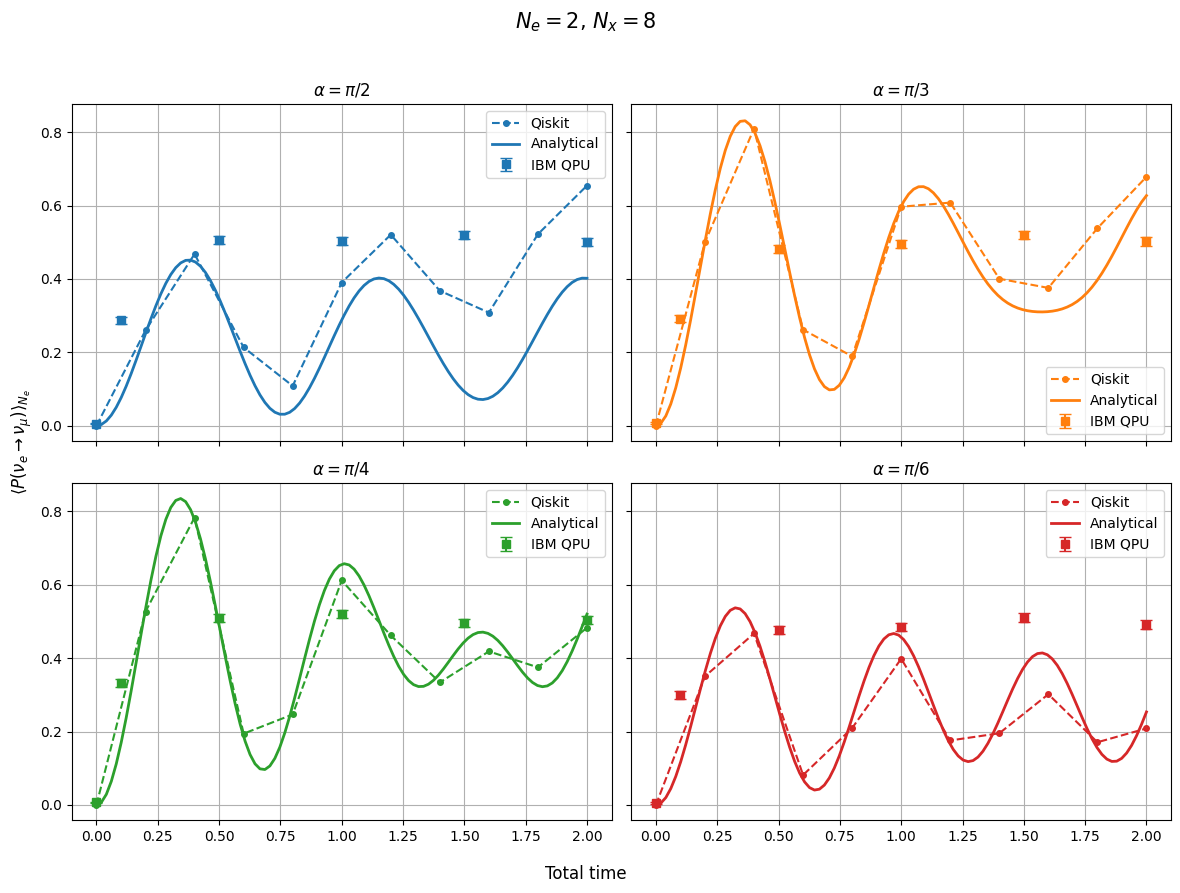

In [18]:
# =====================================================
# Final comparison:
# Qiskit vs Analytical vs IBM
# =====================================================

alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]

P_mb = {}
P_emu = {}
P_ibm = {}
P_ibm_std = {}

# -----------------------------------------------------
# Initialize IBM Runtime
# -----------------------------------------------------

if run_ibm:
    initialize_ibm_runtime()

# -----------------------------------------------------
# Analytical time grid
# -----------------------------------------------------

t_analytic = np.linspace(0, 2.0, 100)

# -----------------------------------------------------
# Figure
# -----------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# -----------------------------------------------------
# Run all alpha cases
# -----------------------------------------------------

for ax, (alpha, alpha_label), color in zip(
    axes,
    alpha_cases,
    colors,
):

    print()
    print("#" * 70)
    print(f"ALPHA = {alpha_label}")
    print("#" * 70)

    # =================================================
    # 1. QISKIT MANY-BODY
    # =================================================

    print()
    print("Running Qiskit many-body simulation...")

    result = run_and_plot_alpha(
        alpha,
        alpha_label,
        show_plot=False,
        verbose=True,
    )

    P_mb[alpha_label] = (
        result["many_body"]["P_e_to_mu_avg"]
    )

    # =================================================
    # 2. ANALYTICAL EXPRESSION
    # =================================================

    P_emu[alpha_label] = (
        collective_oscillation_probability(
            N1=Ne,
            N2=Nx,
            alpha=alpha,
            t=t_analytic,
            lam=J,
        )
    )

    # =================================================
    # 3. IBM QPU
    # =================================================

    if run_ibm:

        print()
        print("=" * 60)
        print(
            f"Running IBM QPU for alpha = {alpha_label}"
        )
        print("=" * 60)

        ibm_result = run_alpha_case_ibm(
            alpha=alpha,
            alpha_label=alpha_label,
            verbose=True,
        )

        # IBM expectation converted to
        # P(nu_e -> nu_mu)
        P_ibm[alpha_label] = (
            ibm_result["P_e_to_mu_avg"]
        )

        # IBM uncertainty
        P_ibm_std[alpha_label] = (
            ibm_result["P_e_to_mu_std"]
        )

    # =================================================
    # PLOT QISKIT
    # =================================================

    x, xlabel = get_plot_time()

    ax.plot(
        x,
        P_mb[alpha_label],
        "--o",
        color=color,
        markersize=4,
        label="Qiskit",
    )

    # =================================================
    # PLOT ANALYTICAL
    # =================================================

    ax.plot(
        t_analytic,
        P_emu[alpha_label],
        "-",
        color=color,
        linewidth=2,
        label="Analytical",
    )

    # =================================================
    # PLOT IBM
    # =================================================

    if run_ibm:

        ax.errorbar(
            ibm_times,
            P_ibm[alpha_label],
            yerr=P_ibm_std[alpha_label],
            fmt="s",
            color=color,
            markersize=6,
            capsize=4,
            capthick=1,
            linestyle="none",
            label="IBM QPU",
        )

    # =================================================
    # Formatting
    # =================================================

    ax.set_title(
        rf"$\alpha={alpha_label}$"
    )

    ax.grid(True)
    ax.legend()


# -----------------------------------------------------
# Figure labels
# -----------------------------------------------------

fig.supxlabel(xlabel)

fig.supylabel(
    r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$"
)

fig.suptitle(
    rf"$N_e={Ne}$, $N_x={Nx}$",
    fontsize=15,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## 